Importer les bibliothèques nécessaires.

In [16]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import panadas as pd
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical


Load Dataset and Verify Image Files with try expext
Mélanger les images de toutes les classes dans deux listes

rsize the images with opencv (224,224)

In [17]:
valid_ext = ['.jpg', '.jpeg', '.png', '.bmp']

data_path = r'C:\Users\redaj\Desktop\BrainScan\Data'


images, labels = [], []
for folder in os.listdir(data_path):
    for file in os.listdir(os.path.join(data_path, folder)):
        ext = os.path.splitext(file)[1].lower() # split by name of the file and extension
        if ext in valid_ext:
            try:
                img = cv2.imread(os.path.join(data_path, folder, file))#cv2.imread() loads the image as a NumPy array (height × width × channels).

                images_resized = cv2.resize(img, (224,224))
                images.append(images_resized)
                labels.append(folder)
            except Exception as e:
                print(f"find an erur loading the file {file} : {e}")

print(images)         
print(labels)       

[array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(224, 224, 3), dtype=uint8), array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0

Task 1.3: Explore Dataset Structure

Visualiser un échantillon d’images pour chaque classe

Classes found: ['glioma' 'meningioma' 'notumor' 'pituitary']


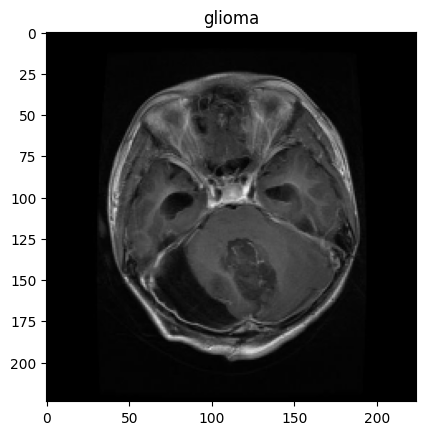

In [18]:
classes = np.unique(labels)

shuffle(images , labels ,)
print("Classes found:", classes)
plt.imshow(cv2.cvtColor(images[0], cv2.COLOR_BGR2RGB))
plt.title(labels[0])
plt.show()


Afficher graphiquement le nombre d’images dans chaque classe.

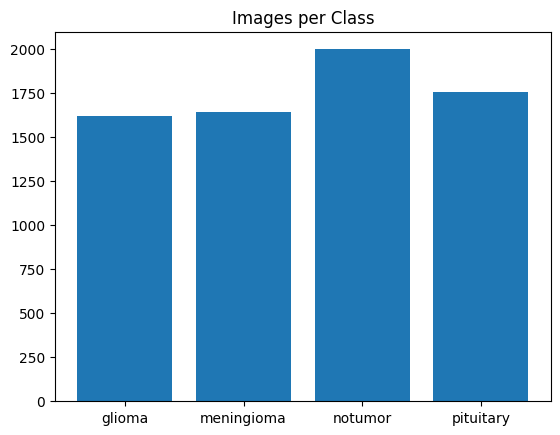

In [19]:
from collections import Counter
plt.bar(Counter(labels).keys(), Counter(labels).values())
plt.title("Images per Class")
plt.show()


convertir les listes images et étiquettes en tableaux NumPy pour les rendre exploitables par le modèle CNN.

In [20]:
images = np.array(images)
labels = np.array(labels)
count_images = Counter(labels)
keys = count_images.keys()


#print(images.shape)
print(labels)


['glioma' 'glioma' 'glioma' ... 'pituitary' 'pituitary' 'pituitary']


In [21]:
# import cv2
# import numpy as np

# def augment_image(img):
#     flipped = cv2.flip(img, 1)          # horizontal flip
#     rotated = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
#     return [flipped, rotated]

# aug_images, aug_labels = [], []
# class_counts = Counter(labels)
# # Get names of classes that are not 'notumor'
# columns_buff = [cls for cls in class_counts.keys() if cls != 'notumor']


# for cls in class_counts.keys():
#     idx = np.where(labels == cls)[0]
#     while len(idx) < 2000:
#         for i in np.where(labels == cls)[0]:
#             new_imgs = augment_image(images[i])
#             aug_images.extend(new_imgs)
#             aug_labels.extend([cls] * len(new_imgs))
#         idx = np.append(idx, np.where(labels == cls)[0])

# images = np.concatenate((images, np.array(aug_images)), axis=0)
##labels = np.concatenate((labels, np.array(aug_labels)), axis=0)


In [22]:
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# import numpy as np
# from collections import Counter

# # Print original class distribution
# original_class_counts = Counter(labels)
# print("Original class distribution:")
# print(original_class_counts)

# datagen = ImageDataGenerator(
#     rotation_range=15,
#     width_shift_range=0.1,
#     height_shift_range=0.1,
#     zoom_range=0.1,
#     horizontal_flip=True
# )

# # Convert labels to numpy array if not already
# labels_array = labels

# # Initialize collections for all augmented data
# all_augmented_images = []
# all_augmented_labels = []

# # Get the target count for each class
# target_count = 2000

# # Process each class that has fewer than 2000 samples
# for class_name, count in original_class_counts.items():
#     if count < target_count:
#         print(f"Augmenting class '{class_name}' from {count} to {target_count} samples")
        
#         # Get images for current class
#         class_mask = labels_array == class_name
#         class_images = images[class_mask]
        
#         # Calculate how many new images to generate
#         num_to_generate = target_count - count
        
#         # Generate augmented images for this class
#         augmented_images = []
#         augmented_labels = []
#         generated = 0
        
#         for batch in datagen.flow(class_images, batch_size=1):
#             augmented_images.append(batch[0])
#             augmented_labels.append(class_name)
#             generated += 1
#             if generated >= num_to_generate:
#                 break
                
#         # Add this class's augmented data to the overall collection
#         all_augmented_images.extend(augmented_images)
#         all_augmented_labels.extend(augmented_labels)

# # Convert augmented data to numpy arrays
# all_augmented_images = np.array(all_augmented_images)
# all_augmented_labels = np.array(all_augmented_labels)

# # Add the augmented data to the original data
# if len(all_augmented_images) > 0:
#     # Combine images
#     images = np.concatenate((images, all_augmented_images), axis=0)
    
#     # Combine labels
#     labels = np.concatenate((labels_array, all_augmented_labels), axis=0)
    
#     # Print the new class distribution
#     new_class_counts = Counter(labels)
#     print("\nNew class distribution after augmentation:")
#     print(new_class_counts)
# else:
#     print("No augmentation needed - all classes already have at least 2000 samples")

In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from collections import Counter

# Print original class distribution
original_class_counts = Counter(labels)
print("Original class distribution:")
print(original_class_counts)

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Convert labels to numpy array if not already
labels_array = np.array(labels)

# Initialize collections for all augmented data
all_augmented_images = []
all_augmented_labels = []

# Get the target count for each class
target_count = 2000

# Process each class that has fewer than 2000 samples
for class_name, count in original_class_counts.items():
    if count < target_count:
        print(f"Augmenting class '{class_name}' from {count} to {target_count} samples")
        
        # Get images for current class
        class_mask = labels_array == class_name
        class_images = images[class_mask]
        
        # Calculate how many new images to generate
        num_to_generate = target_count - count
        
        # Generate augmented images for this class
        augmented_images = []
        augmented_labels = []
        generated = 0
        
        for batch in datagen.flow(class_images, batch_size=1):
            augmented_images.append(batch[0])
            augmented_labels.append(class_name)
            generated += 1
            if generated >= num_to_generate:
                break
                
        # Add this class's augmented data to the overall collection
        all_augmented_images.extend(augmented_images)
        all_augmented_labels.extend(augmented_labels)

# Convert augmented data to numpy arrays
all_augmented_images = np.array(all_augmented_images)
all_augmented_labels = np.array(all_augmented_labels)

# Add the augmented data to the original data
if len(all_augmented_images) > 0:
    # Combine images
    images = np.concatenate((images, all_augmented_images), axis=0)
    
    # Combine labels
    labels = np.concatenate((labels_array, all_augmented_labels), axis=0)
    
    # Print the new class distribution
    new_class_counts = Counter(labels)
    print("\nNew class distribution after augmentation:")
    print(new_class_counts)
else:
    print("No augmentation needed - all classes already have at least 2000 samples")

Original class distribution:
Counter({np.str_('notumor'): 2000, np.str_('pituitary'): 1757, np.str_('meningioma'): 1645, np.str_('glioma'): 1621})
Augmenting class 'glioma' from 1621 to 2000 samples
Augmenting class 'meningioma' from 1645 to 2000 samples
Augmenting class 'meningioma' from 1645 to 2000 samples
Augmenting class 'pituitary' from 1757 to 2000 samples
Augmenting class 'pituitary' from 1757 to 2000 samples

New class distribution after augmentation:
Counter({np.str_('glioma'): 2000, np.str_('meningioma'): 2000, np.str_('notumor'): 2000, np.str_('pituitary'): 2000})

New class distribution after augmentation:
Counter({np.str_('glioma'): 2000, np.str_('meningioma'): 2000, np.str_('notumor'): 2000, np.str_('pituitary'): 2000})


In [24]:
class_counts = Counter(labels)


print(class_counts)


Counter({np.str_('glioma'): 2000, np.str_('meningioma'): 2000, np.str_('notumor'): 2000, np.str_('pituitary'): 2000})


In [25]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Encode the labels into numerical values
encoder = LabelEncoder()
labels_encoded = encoder.fit_transform(labels)

# Convert the encoded labels into categorical format
labels_categorical = to_categorical(labels_encoded)

# Print the first 5 encoded labels for verification
print("Encoded labels (first 5):", labels_encoded[:5])
print("Categorical labels (first 5):")
print(labels_categorical[:5])

Encoded labels (first 5): [0 0 0 0 0]
Categorical labels (first 5):
[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]


split

In [26]:
from sklearn.model_selection import train_test_split

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    images, labels_categorical, test_size=0.2, random_state=42, stratify=labels
)

# Afficher les dimensions des ensembles
print("Taille de l'ensemble d'entraînement :", X_train.shape, y_train.shape)
print("Taille de l'ensemble de test :", X_test.shape, y_test.shape)

Taille de l'ensemble d'entraînement : (6400, 224, 224, 3) (6400, 4)
Taille de l'ensemble de test : (1600, 224, 224, 3) (1600, 4)


normalization des pixels 

In [27]:
images = np.array(images, dtype=np.float32) / 255.0